- import packages

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib

from anomaly_detection.data.split import time_series_split
from anomaly_detection.features.build_features import select_feature_columns, build_feature_matrix
from anomaly_detection.models.evaluate import (
    isolation_forest_pred_to_anomaly,
    compute_metrics,
)

- load artifacts

In [2]:
metrics_path = Path("../artifacts/metrics/baseline_isolation_forest.json")
model_path = Path("../artifacts/models/isolation_forest.joblib")

metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
model = joblib.load(model_path)

metrics["aggregate"], list(metrics["per_file"].keys())[:5]

({'precision': 0.37478942845805713,
  'recall': 0.32901455740980107,
  'f1': 0.3367609735930206,
  'support': 8216},
 ['0.csv', '1.csv', '10.csv', '11.csv', '12.csv'])

In [3]:
processed_dir = Path("../data/processed/skab")

files = list(processed_dir.glob("*.csv"))
files_with_anomalies = []

for p in files:
    df_tmp = pd.read_csv(p)
    if df_tmp["anomaly"].sum() > 0:
        files_with_anomalies.append(p)

files_with_anomalies[:5]

csv_path = files_with_anomalies[0]
file_name = csv_path.name

df = pd.read_csv(csv_path)
csv_path.name, df["anomaly"].sum()

('3.csv', np.float64(395.0))

- split and feature matrix

In [4]:
timestamp_col = "timestamp"
label_col = "anomaly"
train_ratio = metrics.get("train_ratio", 0.7)

train_df, test_df = time_series_split(df, train_ratio=train_ratio)

feature_cols = select_feature_columns(df, timestamp_col=timestamp_col, label_col=label_col)
expected = list(model.feature_names_in_) if hasattr(model, "feature_names_in_") else None
X_test = build_feature_matrix(test_df, feature_cols, expected_features=expected)

y_true = test_df[label_col].to_numpy().astype(int)

len(train_df), len(test_df), X_test.shape


(696, 299, (299, 8))

- prediction and scores

In [5]:
raw_pred = model.predict(X_test)                       # -1 / 1
y_pred = isolation_forest_pred_to_anomaly(raw_pred)    # 0 / 1

# as less the score, more anomaly (typical for sklearn)
scores = model.decision_function(X_test)

m = compute_metrics(y_true=y_true, y_pred=y_pred)
m

ClassificationMetrics(precision=0.8795986622073578, recall=1.0, f1=0.9359430604982206, support=299)

- confusion-counts and indices

In [6]:
tp = int(((y_true == 1) & (y_pred == 1)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
tn = int(((y_true == 0) & (y_pred == 0)).sum())

tp, fp, fn, tn

(263, 36, 0, 0)

In [7]:
fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]

len(fp_idx), len(fn_idx), fp_idx[:10], fn_idx[:10]

(36,
 0,
 array([263, 264, 265, 266, 267, 268, 269, 270, 271, 272]),
 array([], dtype=int64))

- plots

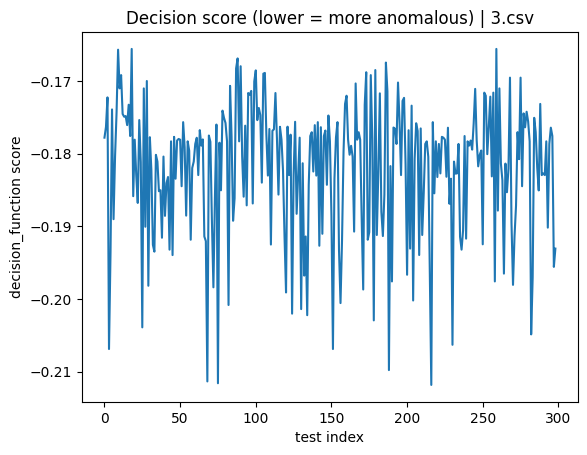

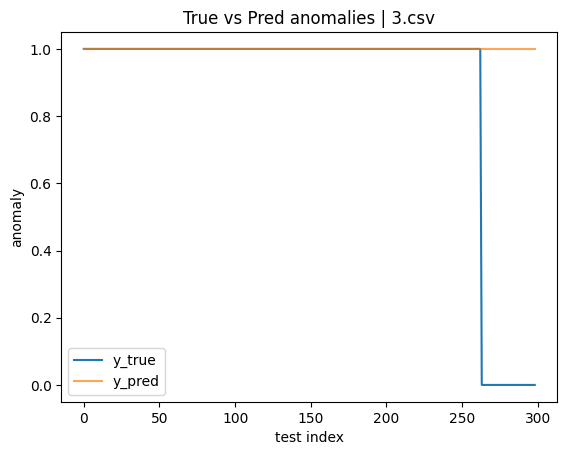

In [8]:
t = np.arange(len(test_df))

plt.figure()
plt.plot(t, scores)
plt.title(f"Decision score (lower = more anomalous) | {file_name}")
plt.xlabel("test index")
plt.ylabel("decision_function score")
plt.show()

plt.figure()
plt.plot(t, y_true, label="y_true")
plt.plot(t, y_pred, label="y_pred", alpha=0.7)
plt.title(f"True vs Pred anomalies | {file_name}")
plt.xlabel("test index")
plt.ylabel("anomaly")
plt.legend()
plt.show()

In [9]:
sensor_cols = list(X_test.columns)
sensor_cols[:10]

['Accelerometer1RMS',
 'Accelerometer2RMS',
 'Current',
 'Pressure',
 'Temperature',
 'Thermocouple',
 'Voltage',
 'Volume Flow RateRMS']

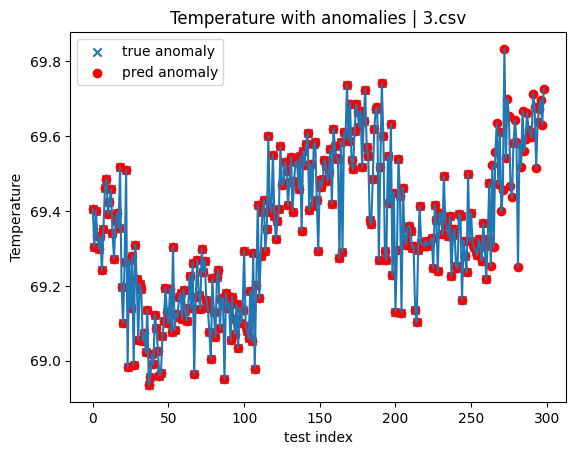

In [12]:
col = sensor_cols[4]
x = test_df[col].to_numpy()

plt.figure()
plt.plot(t, x)
plt.scatter(t[y_true == 1], x[y_true == 1], marker="x", label="true anomaly")
plt.scatter(t[y_pred == 1], x[y_pred == 1], marker="o", facecolors="r", label="pred anomaly")
plt.title(f"{col} with anomalies | {file_name}")
plt.xlabel("test index")
plt.ylabel(col)
plt.legend()
plt.show()

In [11]:
true_rate = float((y_true == 1).mean())
pred_rate = float((y_pred == 1).mean())
true_rate, pred_rate

(0.8795986622073578, 1.0)